In [1]:
import json
import math
import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# ── Discover all JSON files from both workflow folders ──────────────────────
BASE = Path.cwd()
FOLDERS = {"1000Genome": BASE / "1000Genome", "epigenomics": BASE / "epigenomics"}

workflow_files = []  # list of dicts: {path, dataset, num_ch, size}
for dataset, folder in FOLDERS.items():
    for p in sorted(folder.glob("*.json")):
        m = re.search(r"-(\d+)ch-(\d+k)-", p.stem)
        if m:
            workflow_files.append(
                dict(path=p, dataset=dataset, num_ch=int(m.group(1)), size=m.group(2))
            )

print(f"Found {len(workflow_files)} workflow files:")
for wf in workflow_files:
    print(f"  [{wf['dataset']}] {wf['path'].name}  (ch={wf['num_ch']}, size={wf['size']})")


Found 44 workflow files:
  [1000Genome] 1000genome-chameleon-10ch-100k-001.json  (ch=10, size=100k)
  [1000Genome] 1000genome-chameleon-10ch-250k-001.json  (ch=10, size=250k)
  [1000Genome] 1000genome-chameleon-12ch-100k-001.json  (ch=12, size=100k)
  [1000Genome] 1000genome-chameleon-12ch-250k-001.json  (ch=12, size=250k)
  [1000Genome] 1000genome-chameleon-14ch-100k-001.json  (ch=14, size=100k)
  [1000Genome] 1000genome-chameleon-14ch-250k-001.json  (ch=14, size=250k)
  [1000Genome] 1000genome-chameleon-16ch-100k-001.json  (ch=16, size=100k)
  [1000Genome] 1000genome-chameleon-16ch-250k-001.json  (ch=16, size=250k)
  [1000Genome] 1000genome-chameleon-18ch-100k-001.json  (ch=18, size=100k)
  [1000Genome] 1000genome-chameleon-18ch-250k-001.json  (ch=18, size=250k)
  [1000Genome] 1000genome-chameleon-20ch-100k-001.json  (ch=20, size=100k)
  [1000Genome] 1000genome-chameleon-20ch-250k-001.json  (ch=20, size=250k)
  [1000Genome] 1000genome-chameleon-22ch-100k-001.json  (ch=22, size=100k)


In [2]:
# ── Helper utilities ────────────────────────────────────────────────────────
def as_float(value, default=0.0):
    if value is None:
        return default
    if isinstance(value, (int, float)):
        if isinstance(value, float) and math.isnan(value):
            return default
        return float(value)
    if isinstance(value, str):
        s = value.strip()
        if s == "":
            return default
        try:
            return float(s)
        except Exception:
            return default
    return default


def to_list(x):
    if x is None:
        return []
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, str):
        s = x.strip()
        if s == "":
            return []
        try:
            v = json.loads(s)
            if isinstance(v, list):
                return v
        except Exception:
            pass
        return [s]
    return []


def normalize_parent(p):
    if isinstance(p, dict):
        for key in ("name", "id", "task", "job", "node"):
            if key in p and p[key] is not None:
                return str(p[key])
        return None
    if p is None:
        return None
    return str(p)


# ── Load one workflow JSON → (ids, runtime_by_id, selected_parent, children_tree) ──
def load_workflow(path: Path):
    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)

    workflow_obj = payload.get("workflow", payload if isinstance(payload, dict) else {})
    jobs = workflow_obj.get("jobs")
    if not isinstance(jobs, list):
        jobs = workflow_obj.get("tasks", [])
    if not isinstance(jobs, list):
        raise RuntimeError(f"No jobs/tasks list found in {path.name}")

    task_data = {}
    for job in jobs:
        if not isinstance(job, dict):
            continue
        task_id = job.get("name") or job.get("id") or job.get("task_id")
        if task_id is None:
            continue
        task_id = str(task_id)
        runtime = as_float(
            job.get("runtimeInSeconds", job.get("runtime", job.get("executionTime", 0.0))), 0.0
        )
        parent_candidates = to_list(job.get("parents", job.get("parent", [])))
        parents = [normalize_parent(p) for p in parent_candidates]
        parents = [p for p in parents if p is not None and p != task_id]

        if task_id not in task_data:
            task_data[task_id] = {"runtime": runtime, "parents": []}
        task_data[task_id]["runtime"] = max(task_data[task_id]["runtime"], runtime)
        task_data[task_id]["parents"].extend(parents)

    ids = list(task_data.keys())
    runtime_by_id = {k: float(v["runtime"]) for k, v in task_data.items()}

    parents_by_id = {}
    for node in ids:
        seen, plist = set(), []
        for p in task_data[node]["parents"]:
            if p in runtime_by_id and p not in seen and p != node:
                seen.add(p)
                plist.append(p)
        parents_by_id[node] = plist

    # keep one parent per node (heaviest) to form a tree
    selected_parent = {}
    for node in ids:
        plist = parents_by_id.get(node, [])
        if not plist:
            selected_parent[node] = None
        elif len(plist) == 1:
            selected_parent[node] = plist[0]
        else:
            selected_parent[node] = max(plist, key=lambda p: runtime_by_id.get(p, float("-inf")))

    children_tree = {node: [] for node in ids}
    for node, parent in selected_parent.items():
        if parent is not None:
            children_tree[parent].append(node)

    return ids, runtime_by_id, selected_parent, children_tree


print("Helper functions and load_workflow() defined.")


Helper functions and load_workflow() defined.


In [3]:
class NaiveMaxPath:

    def __init__(self, parent_map, value_map):

        self.parent_map = parent_map

        self.value_map = value_map



    def query_to_root(self, node):

        cur = node

        best = float("-inf")

        while cur is not None:

            val = self.value_map.get(cur, float("-inf"))

            if val > best:

                best = val

            cur = self.parent_map.get(cur)

        return best



class SegmentTreeMax:

    def __init__(self, arr):

        n = len(arr)

        size = 1

        while size < n:

            size <<= 1

        self.size = size

        self.seg = [float("-inf")] * (2 * size)

        for i, v in enumerate(arr):

            self.seg[size + i] = v

        for i in range(size - 1, 0, -1):

            self.seg[i] = max(self.seg[i << 1], self.seg[i << 1 | 1])



    def query(self, left, right):

        left += self.size

        right += self.size

        res = float("-inf")

        while left <= right:

            if left & 1:

                res = max(res, self.seg[left])

                left += 1

            if not (right & 1):

                res = max(res, self.seg[right])

                right -= 1

            left >>= 1

            right >>= 1

        return res



class HLDMaxPath:

    def __init__(self, nodes, roots, children_tree, value_map):

        self.nodes = nodes

        self.index_of = {node: i for i, node in enumerate(nodes)}

        n = len(nodes)

        self.parent = [-1] * n

        self.depth = [0] * n

        self.heavy = [-1] * n

        self.head = [0] * n

        self.pos = [0] * n

        self.sub_size = [1] * n

        self.children = [[] for _ in range(n)]

        self.value = [0.0] * n

        for node in nodes:

            i = self.index_of[node]

            self.value[i] = float(value_map.get(node, 0.0))

            self.children[i] = [self.index_of[c] for c in children_tree.get(node, []) if c in self.index_of]



        order = []

        root_indices = [self.index_of[r] for r in roots if r in self.index_of]

        for r in root_indices:

            stack = [r]

            self.parent[r] = -1

            self.depth[r] = 0

            while stack:

                v = stack.pop()

                order.append(v)

                for c in self.children[v]:

                    self.parent[c] = v

                    self.depth[c] = self.depth[v] + 1

                    stack.append(c)



        for v in reversed(order):

            size_v = 1

            heavy_child = -1

            heavy_size = 0

            for c in self.children[v]:

                size_v += self.sub_size[c]

                if self.sub_size[c] > heavy_size:

                    heavy_size = self.sub_size[c]

                    heavy_child = c

            self.sub_size[v] = size_v

            self.heavy[v] = heavy_child



        cur_pos = 0

        base = [0.0] * n

        for r in root_indices:

            stack = [(r, r)]

            while stack:

                v, h = stack.pop()

                while v != -1:

                    self.head[v] = h

                    self.pos[v] = cur_pos

                    base[cur_pos] = self.value[v]

                    cur_pos += 1

                    hv = self.heavy[v]

                    for c in self.children[v]:

                        if c != hv:

                            stack.append((c, c))

                    v = hv



        self.seg = SegmentTreeMax(base)



    def query_to_root(self, node):

        v = self.index_of[node]

        res = float("-inf")

        while v != -1:

            h = self.head[v]

            res = max(res, self.seg.query(self.pos[h], self.pos[v]))

            v = self.parent[h]

        return res


In [7]:
# ── Per-file benchmark configuration ────────────────────────────────────────
NUM_QUERIES       = 5_000   # queries per file
EXTENSION_DEPTH   = 20      # extra chain added from each seed leaf (reduced from 100)
MAX_SEED_LEAVES   = 50      # cap on seed leaves used for extension (reduced from 200)
rng = np.random.default_rng(42)


def path_length_to_root(node, parent_map):
    length, cur = 0, node
    while cur is not None:
        length += 1
        cur = parent_map.get(cur)
    return length


def benchmark_workflow(ids, runtime_by_id, selected_parent, children_tree):
    """Run Naive vs HLD benchmark on one workflow tree. Returns metrics dict."""
    # ── tree extension to create long chains ────────────────────────────────
    b_parent  = dict(selected_parent)
    b_runtime = dict(runtime_by_id)
    b_children = {n: list(c) for n, c in children_tree.items()}

    base_leaves = [n for n, c in b_children.items() if len(c) == 0]
    if not base_leaves:
        raise RuntimeError("No leaves found")

    seed_leaves = (
        base_leaves if len(base_leaves) <= MAX_SEED_LEAVES
        else rng.choice(base_leaves, size=MAX_SEED_LEAVES, replace=False).tolist()
    )
    for leaf in seed_leaves:
        prev = leaf
        base_rt = b_runtime.get(leaf, 0.0)
        for d in range(EXTENSION_DEPTH):
            nn = f"{leaf}__ext_{d}"
            b_parent[nn]  = prev
            b_runtime[nn] = float(base_rt) * (1.0 + (d + 1) * 1e-6)
            b_children.setdefault(prev, []).append(nn)
            b_children[nn] = []
            prev = nn

    b_ids    = list(b_runtime.keys())
    b_roots  = [n for n, p in b_parent.items() if p is None]
    b_leaves = [n for n, c in b_children.items() if len(c) == 0]

    # ── build structures ─────────────────────────────────────────────────────
    naive = NaiveMaxPath(b_parent, b_runtime)

    hld_t0 = time.perf_counter()
    hld    = HLDMaxPath(b_ids, b_roots, b_children, b_runtime)
    hld_build_time = time.perf_counter() - hld_t0

    # ── pick query nodes (from extended leaves) ───────────────────────────────
    q_nodes = rng.choice(b_leaves, size=NUM_QUERIES, replace=True).tolist()

    # warmup
    for n in q_nodes[:200]:
        naive.query_to_root(n)
        hld.query_to_root(n)

    # ── timed runs ───────────────────────────────────────────────────────────
    naive_lat, naive_res = [], []
    t0 = time.perf_counter()
    for n in q_nodes:
        ts = time.perf_counter_ns()
        ans = naive.query_to_root(n)
        naive_lat.append((time.perf_counter_ns() - ts) / 1e6)
        naive_res.append(ans)
    naive_total = time.perf_counter() - t0

    hld_lat, hld_res = [], []
    t0 = time.perf_counter()
    for n in q_nodes:
        ts = time.perf_counter_ns()
        ans = hld.query_to_root(n)
        hld_lat.append((time.perf_counter_ns() - ts) / 1e6)
        hld_res.append(ans)
    hld_total = time.perf_counter() - t0

    if not np.allclose(
        np.array(naive_res, dtype=float), np.array(hld_res, dtype=float), equal_nan=True
    ):
        raise RuntimeError("Naive and HLD results differ!")

    avg_path = float(
        np.mean([path_length_to_root(n, b_parent) for n in q_nodes[:500]])
    )

    return dict(
        naive_total=naive_total,
        hld_total=hld_total,
        hld_build=hld_build_time,
        naive_mean_ms=float(np.mean(naive_lat)),
        hld_mean_ms=float(np.mean(hld_lat)),
        naive_max_ms=float(np.max(naive_lat)),
        hld_max_ms=float(np.max(hld_lat)),
        speedup=naive_total / hld_total if hld_total > 0 else float("nan"),
        num_nodes=len(b_ids),
        avg_path_len=avg_path,
    )


# ── Run across all files ─────────────────────────────────────────────────────
all_results = []
total = len(workflow_files)
for i, wf in enumerate(workflow_files, 1):
    print(f"[{i:2d}/{total}] {wf['dataset']:12s}  ch={wf['num_ch']:2d}  size={wf['size']}  ...", end=" ", flush=True)
    try:
        ids, runtime_by_id, selected_parent, children_tree = load_workflow(wf["path"])
        metrics = benchmark_workflow(ids, runtime_by_id, selected_parent, children_tree)
        row = {**wf, **metrics}
        row.pop("path")          # not JSON-serialisable; not needed downstream
        all_results.append(row)
        print(f"speedup={metrics['speedup']:.2f}x  nodes={metrics['num_nodes']}")
    except Exception as e:
        print(f"ERROR: {e}")

results_df = pd.DataFrame(all_results)
print("\nBenchmark complete.")
print(results_df[["dataset","num_ch","size","num_nodes","avg_path_len",
                   "naive_total","hld_total","speedup"]].to_string(index=False))


[ 1/44] 1000Genome    ch=10  size=100k  ... speedup=0.56x  nodes=1260
[ 2/44] 1000Genome    ch=10  size=250k  ... speedup=0.57x  nodes=1410
[ 3/44] 1000Genome    ch=12  size=100k  ... speedup=0.57x  nodes=1312
[ 4/44] 1000Genome    ch=12  size=250k  ... speedup=0.55x  nodes=1492
[ 5/44] 1000Genome    ch=14  size=100k  ... speedup=0.60x  nodes=1364
[ 6/44] 1000Genome    ch=14  size=250k  ... speedup=0.52x  nodes=1574
[ 7/44] 1000Genome    ch=16  size=100k  ... speedup=0.61x  nodes=1416
[ 8/44] 1000Genome    ch=16  size=250k  ... speedup=0.55x  nodes=1656
[ 9/44] 1000Genome    ch=18  size=100k  ... speedup=0.54x  nodes=1468
[10/44] 1000Genome    ch=18  size=250k  ... speedup=0.56x  nodes=1738
[11/44] 1000Genome    ch=20  size=100k  ... speedup=0.60x  nodes=1520
[12/44] 1000Genome    ch=20  size=250k  ... speedup=0.52x  nodes=1820
[13/44] 1000Genome    ch=22  size=100k  ... speedup=0.55x  nodes=1572
[14/44] 1000Genome    ch=22  size=250k  ... speedup=0.56x  nodes=1902
[15/44] 1000Genome  

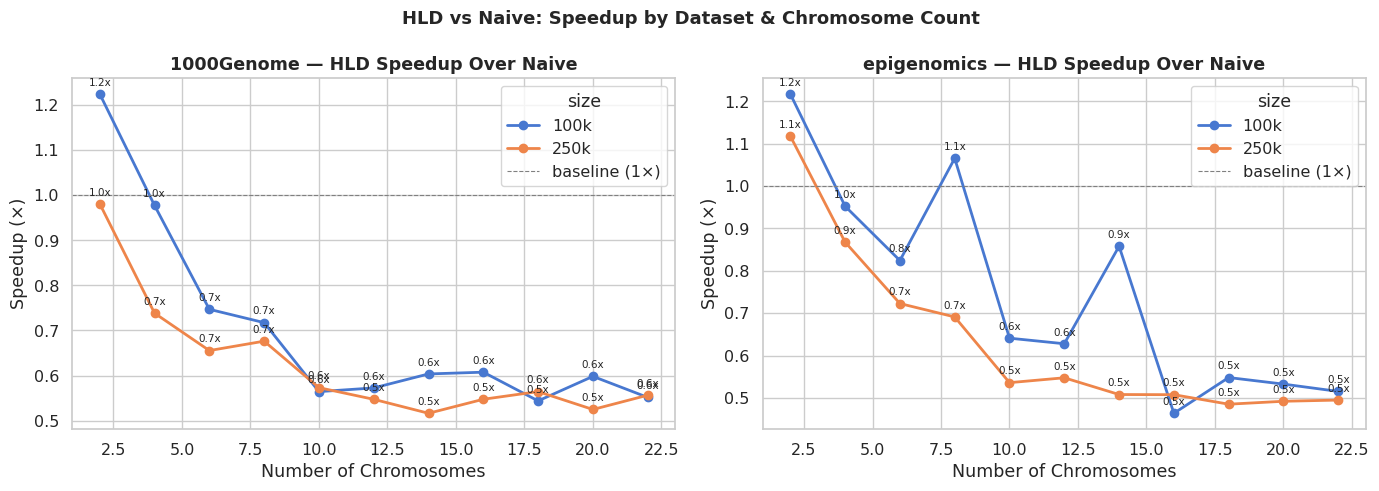

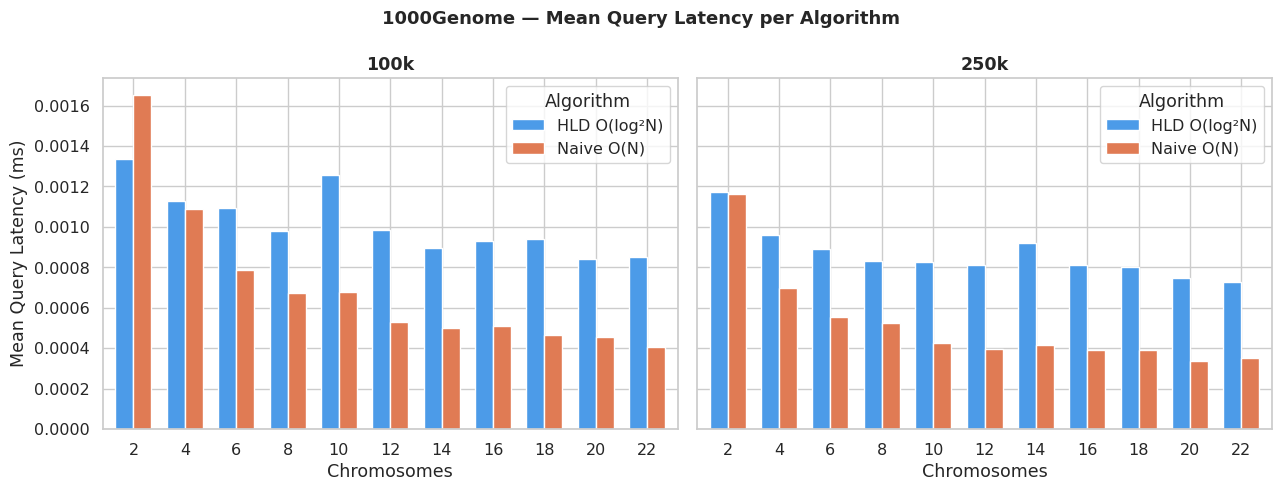

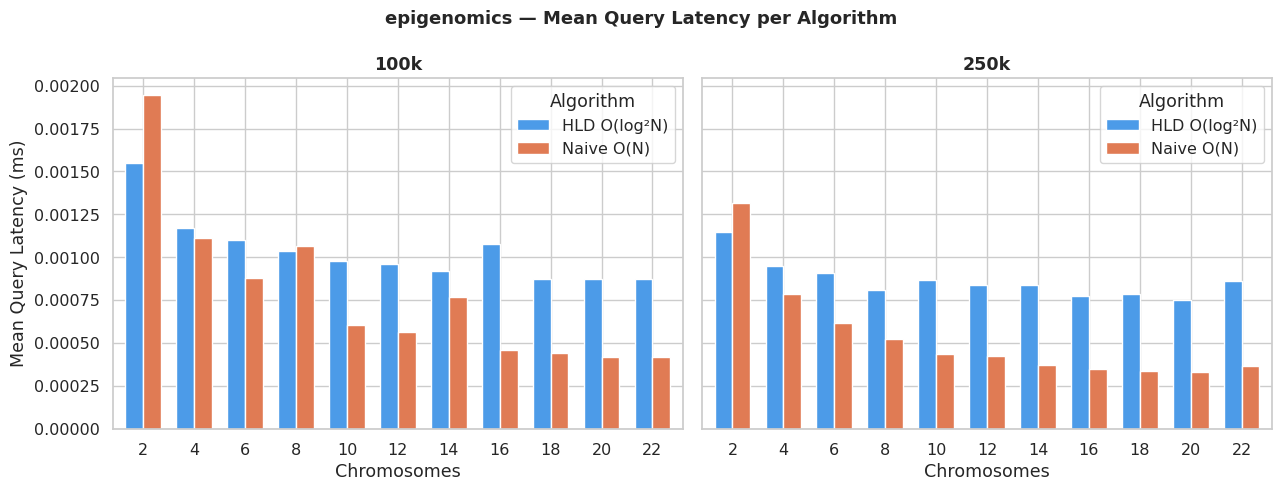

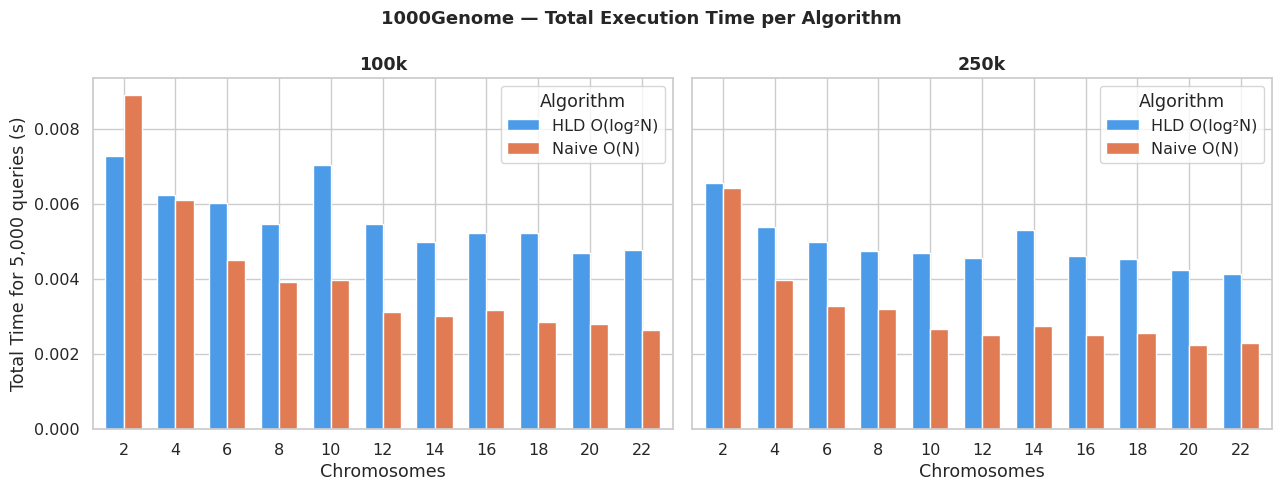

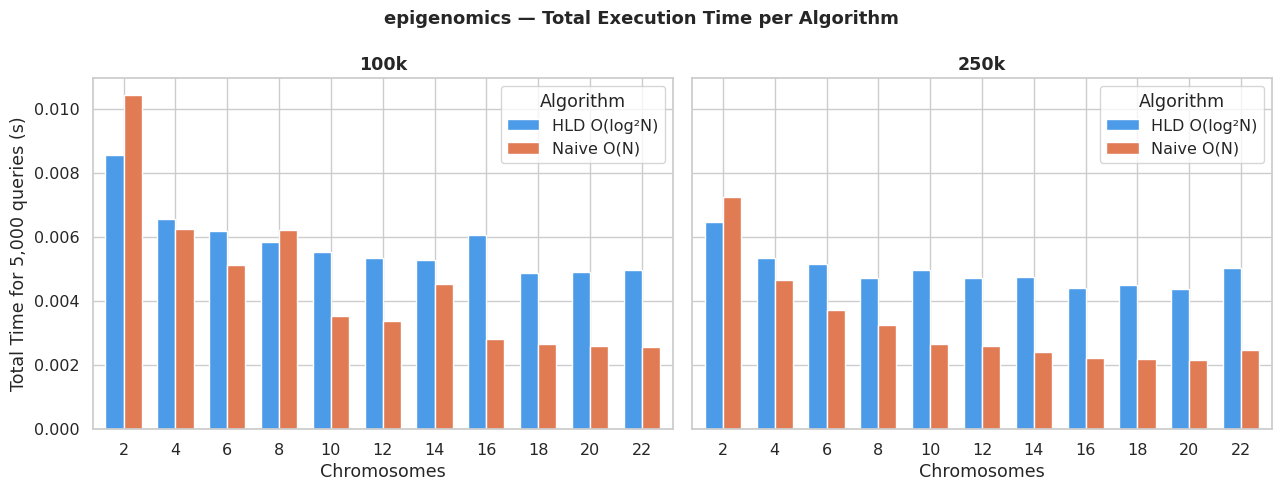

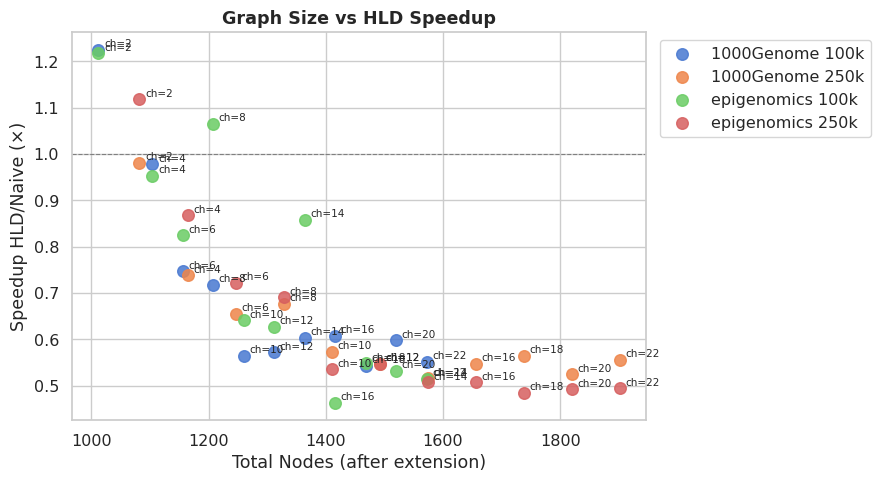


════════════════════════════════════════════════════════════════════════════════════════════════════
NUMERICAL SUMMARY — HLD vs Naive across all workflow files
════════════════════════════════════════════════════════════════════════════════════════════════════
    Dataset  Chromosomes Size  Nodes  Avg Path Len  Naive Mean (ms)  HLD Mean (ms)  Naive Total (s)  HLD Total (s)  Speedup (×)
 1000Genome            2 100k   1012       22.1800           0.0017         0.0013           0.0089         0.0073       1.2251
 1000Genome            4 100k   1104       13.0840           0.0011         0.0011           0.0061         0.0062       0.9776
 1000Genome            6 100k   1156        9.7200           0.0008         0.0011           0.0045         0.0060       0.7470
 1000Genome            8 100k   1208        7.5120           0.0007         0.0010           0.0039         0.0055       0.7174
 1000Genome           10 100k   1260        6.3680           0.0007         0.0013           0.004

In [8]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
ALGO_PALETTE = {"Naive O(N)": "#e07b54", "HLD O(log²N)": "#4c9be8"}

# ── Prepare long-form latency data ───────────────────────────────────────────
long_rows = []
for _, row in results_df.iterrows():
    label = f"{row['dataset']}\nch={row['num_ch']}, {row['size']}"
    long_rows.append(dict(label=label, dataset=row["dataset"],
                          num_ch=row["num_ch"], size=row["size"],
                          Algorithm="Naive O(N)",    latency_ms=row["naive_mean_ms"],
                          total_s=row["naive_total"], speedup=row["speedup"],
                          num_nodes=row["num_nodes"]))
    long_rows.append(dict(label=label, dataset=row["dataset"],
                          num_ch=row["num_ch"], size=row["size"],
                          Algorithm="HLD O(log²N)",  latency_ms=row["hld_mean_ms"],
                          total_s=row["hld_total"],  speedup=row["speedup"],
                          num_nodes=row["num_nodes"]))
long_df = pd.DataFrame(long_rows)

# ════════════════════════════════════════════════════════════════════════════
# 1.  Speedup vs #chromosomes — one line per (dataset, size)
# ════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (ds, grp) in zip(axes, results_df.groupby("dataset")):
    for sz, sg in grp.groupby("size"):
        sg_sorted = sg.sort_values("num_ch")
        ax.plot(sg_sorted["num_ch"], sg_sorted["speedup"],
                marker="o", linewidth=2, label=f"{sz}")
        for _, r in sg_sorted.iterrows():
            ax.annotate(f"{r['speedup']:.1f}x",
                        (r["num_ch"], r["speedup"]),
                        textcoords="offset points", xytext=(0, 6),
                        ha="center", fontsize=7.5)
    ax.axhline(1, color="gray", linestyle="--", linewidth=0.8, label="baseline (1×)")
    ax.set_title(f"{ds} — HLD Speedup Over Naive", fontweight="bold")
    ax.set_xlabel("Number of Chromosomes")
    ax.set_ylabel("Speedup (×)")
    ax.legend(title="size")
plt.suptitle("HLD vs Naive: Speedup by Dataset & Chromosome Count", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 2.  Grouped bar: mean query latency — dataset × size × algorithm
# ════════════════════════════════════════════════════════════════════════════
for ds, grp in long_df.groupby("dataset"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, (sz, sg) in zip(axes, grp.groupby("size")):
        sg_sorted = sg.sort_values("num_ch")
        bar_df = sg_sorted.pivot(index="num_ch", columns="Algorithm", values="latency_ms")
        bar_df.plot(kind="bar", ax=ax, color=[ALGO_PALETTE[c] for c in bar_df.columns],
                    edgecolor="white", width=0.7)
        ax.set_title(f"{sz}", fontweight="bold")
        ax.set_xlabel("Chromosomes")
        ax.set_ylabel("Mean Query Latency (ms)")
        ax.tick_params(axis="x", rotation=0)
        ax.legend(title="Algorithm")
    plt.suptitle(f"{ds} — Mean Query Latency per Algorithm", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 3.  Total execution time — side-by-side per (dataset, size)
# ════════════════════════════════════════════════════════════════════════════
for ds, grp in long_df.groupby("dataset"):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, (sz, sg) in zip(axes, grp.groupby("size")):
        sg_sorted = sg.sort_values("num_ch")
        bar_df = sg_sorted.pivot(index="num_ch", columns="Algorithm", values="total_s")
        bar_df.plot(kind="bar", ax=ax, color=[ALGO_PALETTE[c] for c in bar_df.columns],
                    edgecolor="white", width=0.7)
        ax.set_title(f"{sz}", fontweight="bold")
        ax.set_xlabel("Chromosomes")
        ax.set_ylabel(f"Total Time for {NUM_QUERIES:,} queries (s)")
        ax.tick_params(axis="x", rotation=0)
        ax.legend(title="Algorithm")
    plt.suptitle(f"{ds} — Total Execution Time per Algorithm", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 4.  Node count vs speedup scatter across both datasets
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
for (ds, sz), grp in results_df.groupby(["dataset", "size"]):
    ax.scatter(grp["num_nodes"], grp["speedup"],
               label=f"{ds} {sz}", s=70, alpha=0.85)
    for _, r in grp.iterrows():
        ax.annotate(f"ch={r['num_ch']}", (r["num_nodes"], r["speedup"]),
                    textcoords="offset points", xytext=(4, 2), fontsize=7.5)
ax.axhline(1, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Total Nodes (after extension)")
ax.set_ylabel("Speedup HLD/Naive (×)")
ax.set_title("Graph Size vs HLD Speedup", fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# 5.  Summary numerical table
# ════════════════════════════════════════════════════════════════════════════
summary = results_df[[
    "dataset", "num_ch", "size", "num_nodes", "avg_path_len",
    "naive_mean_ms", "hld_mean_ms", "naive_total", "hld_total", "speedup"
]].copy()
summary.columns = [
    "Dataset", "Chromosomes", "Size", "Nodes", "Avg Path Len",
    "Naive Mean (ms)", "HLD Mean (ms)", "Naive Total (s)", "HLD Total (s)", "Speedup (×)"
]
summary = summary.sort_values(["Dataset", "Size", "Chromosomes"])

# Pretty-print
float_cols = ["Naive Mean (ms)", "HLD Mean (ms)", "Naive Total (s)", "HLD Total (s)", "Speedup (×)", "Avg Path Len"]
fmt = {c: "{:.4f}" for c in float_cols}
fmt["Nodes"] = "{:,}"
print("\n" + "═" * 100)
print("NUMERICAL SUMMARY — HLD vs Naive across all workflow files")
print("═" * 100)
print(summary.to_string(index=False, float_format="{:.4f}".format))
print("═" * 100)

# Aggregate by dataset
agg = results_df.groupby("dataset").agg(
    mean_speedup=("speedup", "mean"),
    max_speedup=("speedup", "max"),
    min_speedup=("speedup", "min"),
    mean_naive_ms=("naive_mean_ms", "mean"),
    mean_hld_ms=("hld_mean_ms", "mean"),
).reset_index()
print("\nAggregate per Dataset:")
print(agg.to_string(index=False, float_format="{:.4f}".format))
